# 07 - Exploring the data

The Democratic Funnel. Team UL, DIRISA Student Datathon Challenge 2026.

How many South Africans register to vote, how many registered voters actually vote, where turnout is lowest, what
goes together with low turnout, and how young people compare.

Reads: `data/processed/master.csv` (made by `06_master`)
Writes: charts in `reports/figures/q0N_*.png`

Every municipality loses people at two points on the way to the ballot box:

```
Adults who may vote  ->  People who registered  ->  People who voted
        E                        R                       V
           (registration gap)         (turnout gap)
```

Registration rate `r = R / E`, turnout `t = V / R`, and the share of all adults who voted `p = r x t = V / E`.

The questions:

A. Turnout and registration
- Q1. How have registration and turnout changed from 2011 to 2026? (`q01_registration_turnout`)
- Q2. How does turnout differ between provinces? (`q02_provinces`)
- Q3. Which municipalities have the lowest turnout over the years? (`q03_lowest_turnout`)

B. Who
- Q4. Which age group registers least? (`q04_age_groups`)

C. What goes with low turnout
- Q5. Which things about a municipality go with low turnout? (`q05_correlations`)
- Q6. Does low turnout cluster in regions? (`q06_clustering`)
- Q7. Does population density go with low turnout? (`q07_density`)

D. What to do
- Q8. Where should effort go before 4 November 2026? (table)

After each chart we say what we found and, where needed, what the data cannot tell us. Run the setup cells first.

## 0. Setup

In [14]:
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Thato20-M/democratic-funnel.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_DIR = Path("/content/democratic-funnel")
    url = REPO_URL
    try:
        from google.colab import userdata
        url = REPO_URL.replace("https://", f"https://{userdata.get('GITHUB_TOKEN')}@")
    except Exception:
        print("No GITHUB_TOKEN in Colab Secrets - cloning will fail for the private repo")
    if REPO_DIR.exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "-q"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", url, str(REPO_DIR)], check=True)
else:
    REPO_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "src" / "config.py").exists())

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repo:", REPO_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo: /content/democratic-funnel


In [15]:
from src import config
from src.config import INTERIM, PROCESSED, FIGURES

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)

config.make_dirs(); config.set_seed()
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)
print(config.describe())

Environment: Colab
Repo root:   /content/democratic-funnel
Work root:   /content/drive/MyDrive/DIRISA_SDC


### Colours

The same colours mean the same thing here, on the slides and on the dashboard:
- blue: registration
- amber: turnout
- crimson: both problems
- green: healthy
- navy: national figures

Amber and light green are pale on white, so charts that use them also have written labels. `LABELS` turns column
names into plain English.

In [16]:
BLUE, AMBER, CRIMSON, GREEN, NAVY = "#2a78d6", "#eda100", "#a3143a", "#7bc586", "#1b2f5b"
LIGHT_BLUE, LIGHT_AMBER = "#9ec5f0", "#f6d58a"         # light colours for older elections
YEAR_COLOURS = {2011: LIGHT_BLUE, 2016: LIGHT_AMBER, 2021: AMBER}
INK, INK2, GRID, SURFACE = "#0b0b0b", "#4a4a47", "#e4e3de", "#ffffff"

GROUPS = ["Low registration", "Low turnout", "Both low", "Healthy"]
WHAT_TO_SEND = {"Low registration": "registration drive, ID and address help",
                "Low turnout": "voter education and mobilisation",
                "Both low": "both - first priority",
                "Healthy": "nothing urgent"}

LABELS = {
    "r": "Registration rate", "t": "Turnout", "p": "Real participation",
    "leak_reg": "Registration vs typical municipality", "leak_turn": "Turnout vs typical municipality",
    "registered": "Registered voters", "votes_cast": "Votes cast", "eligible_adults": "Adults who may vote",
    "higher_ed_rate": "Adults with higher education", "piped_water_rate": "Households with piped water",
    "electricity_rate": "Households with electricity", "refuse_removal_rate": "Households with refuse removal",
    "log_density": "Population density", "spatial_lag_turnout": "Neighbours' turnout",
    "muni_name": "Municipality", "province": "Province",
}

plt.rcParams.update({                                    # big text, because these charts go on slides
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.titlepad": 12, "axes.labelsize": 12, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "grid.color": GRID, "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 12, "font.size": 12,
})


def tidy(ax, xgrid=False, ygrid=True):
    """Recessive axes: no box, gridlines behind the data only where they help reading."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax


def pct(ax, axis="y"):
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    return ax


def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png", bbox_inches="tight")
    print("saved", name)


def group_of(reg_gap, turn_gap):
    """Below the typical (median) municipality on registration and/or turnout."""
    return pd.Series(np.select([(reg_gap < 0) & (turn_gap < 0), reg_gap < 0, turn_gap < 0],
                               ["Both low", "Low registration", "Low turnout"], "Healthy"),
                     index=reg_gap.index)

## 1. Load and check the data

`master.csv` has one row per municipality per election: 213 municipalities x 4 elections (2011, 2016, 2021, 2026) =
852 rows. The 2011 results are already on today's boundaries (`06_master`). 2026 has registration but no votes,
because that election has not happened yet.

In [17]:
master = pd.read_csv(PROCESSED / "master.csv")
assert master.groupby("election")["muni_code"].nunique().to_dict() == {2011: 213, 2016: 213, 2021: 213, 2026: 213}
assert not master.duplicated(["election", "muni_code"]).any()

# today's municipality names everywhere (some IEC files use older names or CAPITALS)
current_name = master[master["election"] == 2026].set_index("muni_code")["muni_name"]
current_name = current_name.where(~current_name.str.isupper(), current_name.str.title())
master["muni_name"] = master["muni_code"].map(current_name)

held = master[master["election"] < 2026].copy()          # elections that actually happened
y21 = master[master["election"] == 2021].copy()
y26 = master[master["election"] == 2026].copy()

missing = master.isna().groupby(master["election"]).sum().T
print("Missing values per column (only columns with any):")
print(missing[missing.sum(axis=1) > 0].to_string())

Missing values per column (only columns with any):
election                 2011  2016  2021  2026
muni_type                   0     0     0   213
valid_votes                 0     0     0   213
spoilt                      0     0     0   213
votes_cast                  0     0     0   213
turnout                     0     0     0   213
boundary_2016               0     0     0   213
comparable_2011             0     0     0   213
covid_shock                 0     0     0   213
registered_youth          213   213   213     0
byelection_turnout_mean   213   213   213   213
byelection_count          213   213   213   213
t                           0     0     0   213
p                           0     0     0   213
leak_turn                   0     0     0   213
t_prev                    213     0     0     0
r_prev                    213     0     0     0
dt                        213     0     0   213
spatial_lag_turnout         0     0     0   213


Every missing value has a reason. 2026 has no votes or turnout yet. 2011 has no "previous election" columns.
`registered_youth` only exists for 2026, because the IEC only publishes registration by age for the current roll.
The by-election columns are empty because we dropped by-elections (they did not happen everywhere).

## What the numbers mean

- Turnout = votes cast / registered voters
- Registration rate = registered voters / adults who may vote (Census 2022 citizens aged 18+)
- Share of adults who voted = votes cast / adults who may vote

"Turnout" on its own always means the first one. National rates are worked out from totals (all votes / all
registered), not by averaging municipal percentages, so a big metro counts for more than a small town. All rates
are fractions (0.45 = 45%).

# A. Turnout and registration

## Q1. How have registration and turnout changed, 2011 to 2026?

          registered (m)  votes cast (m)  registration %  turnout %
election                                                           
2011               23.62           13.57            59.0       57.4
2016               26.33           15.21            65.8       57.7
2021               26.20           11.95            65.4       45.6
2026               29.23             NaN            73.0        NaN
/n
saved q01_registration_turnout


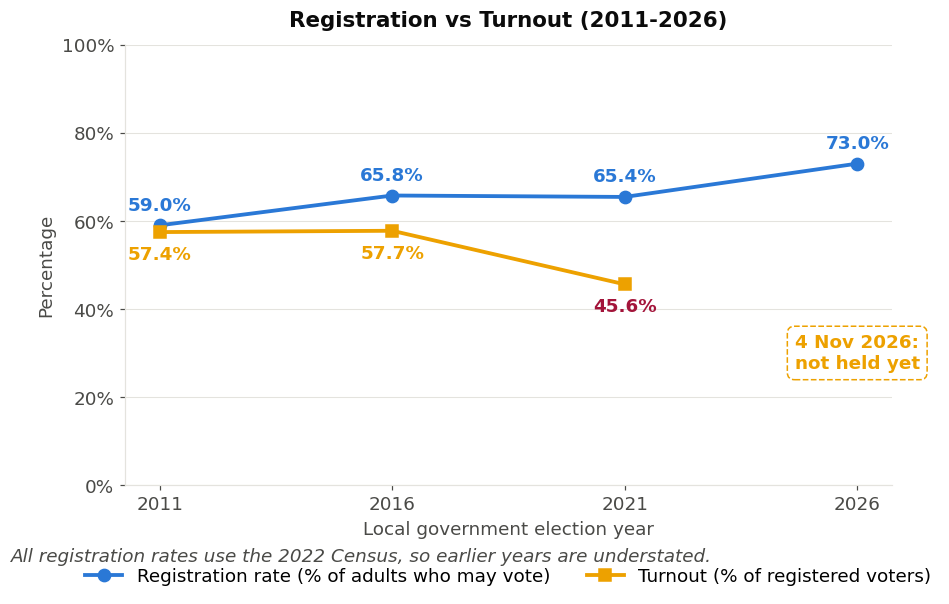

In [33]:
nat = master.groupby("election")[["registered", "votes_cast", "eligible_adults"]].sum(min_count=1)
nat["r"] = nat["registered"] / nat["eligible_adults"]
nat["t"] = nat["votes_cast"] / nat["registered"]
print((nat.assign(registered=lambda d: (d.registered / 1e6).round(2), votes_cast=lambda d: (d.votes_cast / 1e6).round(2),
                  r=lambda d: (d.r * 100).round(1), t=lambda d: (d.t * 100).round(1))
       [["registered", "votes_cast", "r", "t"]]
       .rename(columns={"registered": "registered (m)", "votes_cast": "votes cast (m)",
                        "r": "registration %", "t": "turnout %"}).to_string()))

turnout_held = nat.loc[nat.index < 2026, "t"]
fig, ax = plt.subplots(figsize=(9, 5.2))
print("/n")
ax.plot(nat.index, nat["r"], marker="o", lw=2.5, ms=8, color=BLUE, label="Registration rate (% of adults who may vote)")
ax.plot(turnout_held.index, turnout_held, marker="s", lw=2.5, ms=8, color=AMBER, label="Turnout (% of registered voters)")
for yr, v in nat["r"].items():
    ax.annotate(f"{v:.1%}", (yr, v), textcoords="offset points", xytext=(0, 10), ha="center", weight="bold", color=BLUE)
for yr, v in turnout_held.items():
    ax.annotate(f"{v:.1%}", (yr, v), textcoords="offset points", xytext=(0, -18), ha="center", weight="bold",
                color=CRIMSON if yr == 2021 else AMBER)
ax.annotate("4 Nov 2026:\nnot held yet", (2026, 0.30), ha="center", va="center", fontsize=12, color=AMBER, weight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=AMBER, linestyle="--"))
ax.set_ylim(0, 1); ax.set_xticks(nat.index); pct(ax); tidy(ax)
ax.set(xlabel="Local government election year", ylabel="Percentage", title="Registration vs Turnout (2011-2026)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
fig.text(0.01, -0.06, "All registration rates use the 2022 Census, so earlier years are understated.\n",
         fontsize=12, color=INK2, style="italic")
save(fig, "q01_registration_turnout"); plt.show()

What we found: more adults are on the roll than ever. The registration rate rose from about 59% in 2011 to 73% in
2026. But turnout fell from about 58% to 46% in 2021, the COVID election. So the bigger problem is getting
registered voters to vote.

Keep in mind: every year's registration rate uses the Census 2022 population, because there was no census in 2016 or
2021. There were fewer adults in 2011, so the 2011 rate is too low and the real rise is smaller than the chart shows.
Turnout does not have this problem, because both of its numbers come from the IEC.

## Q2. How does turnout differ between provinces?

saved q02_provinces


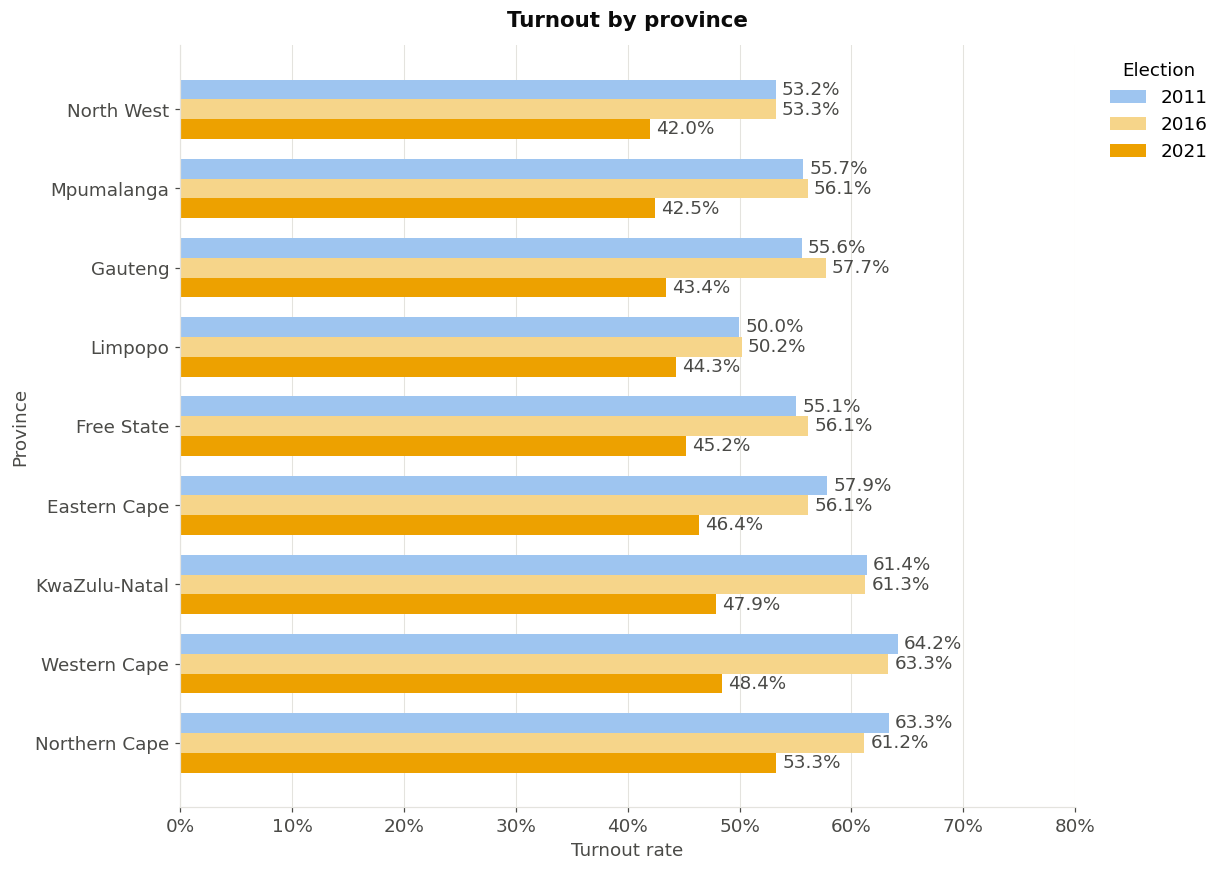

election       2011  2016  2021  change_2016_2021
province                                         
Northern Cape  63.3  61.2  53.3              -7.9
Western Cape   64.2  63.3  48.4             -14.9
KwaZulu-Natal  61.4  61.3  47.9             -13.3
Eastern Cape   57.9  56.1  46.4              -9.7
Free State     55.1  56.1  45.2             -10.9
Limpopo        50.0  50.2  44.3              -5.9
Gauteng        55.6  57.7  43.4             -14.3
Mpumalanga     55.7  56.1  42.5             -13.6
North West     53.2  53.3  42.0             -11.3


In [19]:
prov = held.groupby(["province", "election"])[["registered", "votes_cast"]].sum()
prov = (prov["votes_cast"] / prov["registered"]).unstack("election").sort_values(2021, ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 9))
y, h = np.arange(len(prov)), 0.25
for yr, dy in [(2011, h), (2016, 0), (2021, -h)]:
    bars = ax.barh(y + dy, prov[yr], h, label=str(yr), color=YEAR_COLOURS[yr])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in prov[yr]], padding=4, fontsize=12, color=INK2)
ax.set_yticks(y, prov.index); ax.set_xlim(0, 0.8); pct(ax, "x"); tidy(ax, xgrid=True, ygrid=False)
ax.set(xlabel="Turnout rate", ylabel="Province", title="Turnout by province")
ax.legend(title="Election", loc="upper left", bbox_to_anchor=(1.02, 1))
save(fig, "q02_provinces"); plt.show()

print((prov.assign(change_2016_2021=prov[2021] - prov[2016]) * 100).round(1).to_string())

What we found: turnout fell in every province in 2021, by about 6 to 15 points. The Northern Cape had the highest
turnout in 2021 (53%). The lowest were North West (42.0%), Mpumalanga (42.5%) and Gauteng (43.4%). Limpopo had the
lowest turnout in 2011 and 2016, but the smallest fall in 2021 (about 6 points). The Western Cape, Gauteng,
Mpumalanga and KwaZulu-Natal fell the most (13 to 15 points).

## Q3. Which municipalities have the lowest turnout over the years?

saved q03_lowest_turnout


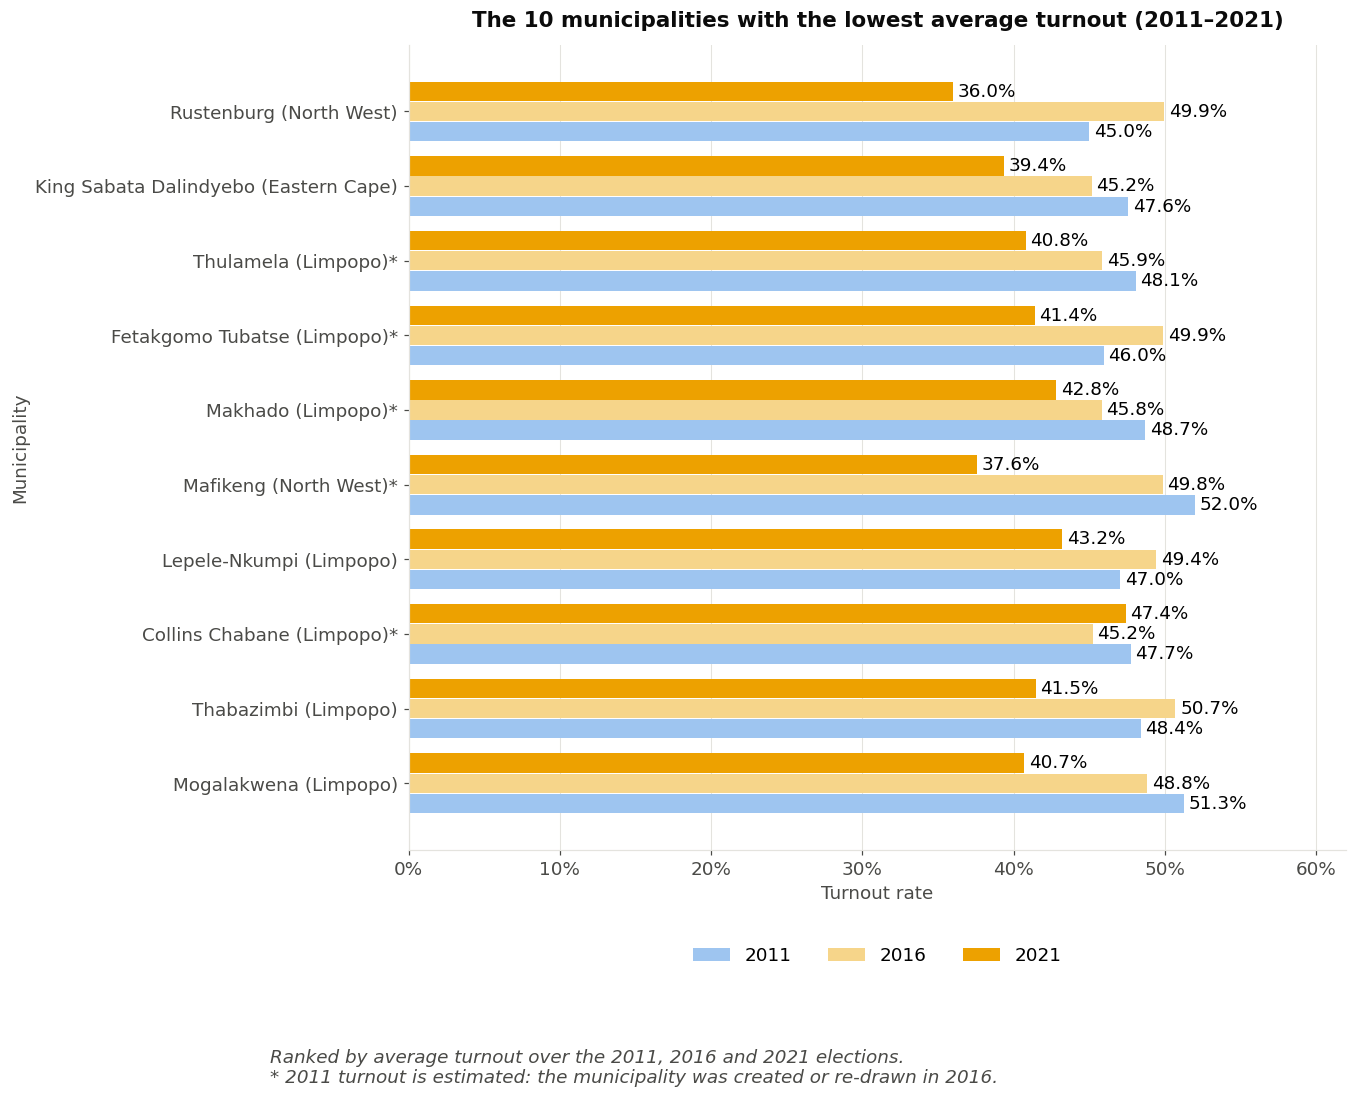

In the bottom 20 in every election: Thabazimbi, Thulamela, Rustenburg, King Sabata Dalindyebo, Mogalakwena, Fetakgomo Tubatse
Biggest falls 2016 -> 2021: Mkhambathini (-23.6), Msunduzi (-19.3), City of Mbombela (-18.7), eThekwini (-18.0), Nelson Mandela Bay (-18.0), City of Cape Town (-17.4)
Of the lowest 10, turnout rose in 2021 in: Collins Chabane
Lowest 10 in 2021 alone: Rustenburg, Mafikeng, Emalahleni, King Sabata Dalindyebo, Govan Mbeki, Mkhambathini, Msukaligwa, Elias Motsoaledi, Mogalakwena, Thembisile Hani


In [20]:
tw = held.pivot_table(index="muni_code", columns="election", values="t")
tw["Average"] = tw[[2011, 2016, 2021]].mean(axis=1)
tw = tw.join(y26.set_index("muni_code")[["muni_name", "province"]])

# 2011 results were moved onto today's boundaries by area share (06_master). Where a municipality was created or
# re-drawn in 2016 (e.g. Collins Chabane), its 2011 turnout is an estimate: flag it.
try:
    cw = pd.read_csv(INTERIM / "muni_crosswalk_2011.csv")
    whole = cw.groupby("muni_code_2011")["share"].transform("sum")
    cw["part"] = cw["share"] / whole                          # share of the old municipality going to this one
    n_old = cw.groupby("muni_code_current")["muni_code_2011"].nunique()
    partial = cw.loc[cw["part"] < 0.99, "muni_code_current"].unique()
    estimated_2011 = set(n_old[n_old > 1].index) | set(partial)
except FileNotFoundError:
    estimated_2011 = set()
    print("muni_crosswalk_2011.csv not found (05_geography) - 2011 estimates are not flagged")

low10 = tw.nsmallest(10, "Average").iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 9.5))
for yr, dy in [(2011, -0.27), (2016, 0), (2021, 0.27)]:
    bars = ax.barh(np.arange(10) + dy, low10[yr], height=0.26, color=YEAR_COLOURS[yr], label=str(yr))
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in low10[yr]], padding=3, fontsize=12)
ax.set_yticks(range(10), [f"{m} ({p})" + ("*" if c in estimated_2011 else "")
                          for c, m, p in zip(low10.index, low10["muni_name"], low10["province"])])
ax.set_xlim(0, 0.62); pct(ax, "x"); tidy(ax, xgrid=True, ygrid=False)
ax.set(title="The 10 municipalities with the lowest average turnout (2011–2021)", xlabel="Turnout rate",
       ylabel="Municipality")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=3)
note = "Ranked by average turnout over the 2011, 2016 and 2021 elections."
if estimated_2011 & set(low10.index):
    note += "\n* 2011 turnout is estimated: the municipality was created or re-drawn in 2016."
fig.text(0.01, -0.08, note, fontsize=12, color=INK2, style="italic", va="top")
save(fig, "q03_lowest_turnout"); plt.show()

bottom20 = [set(tw[yr].nsmallest(20).index) for yr in (2011, 2016, 2021)]
print("In the bottom 20 in every election:", ", ".join(tw.loc[list(set.intersection(*bottom20)), "muni_name"]))
falls = (tw[2021] - tw[2016]).nsmallest(6)
print("Biggest falls 2016 -> 2021:", ", ".join(f"{tw.loc[c, 'muni_name']} ({v * 100:+.1f})" for c, v in falls.items()))
rose = low10[low10[2021] > low10[2016]]
print("Of the lowest 10, turnout rose in 2021 in:", ", ".join(rose["muni_name"]) or "none")
print("Lowest 10 in 2021 alone:", ", ".join(tw.nsmallest(10, 2021)["muni_name"]))

What we found: Rustenburg (North West) has the lowest turnout over the years. It was lowest in 2011 (45.0%) and 2021
(36.0%), and has the lowest average over the three elections (43.7%). The chart ranks municipalities by that average.
Seven of the ten lowest are in Limpopo. Six municipalities were in the bottom 20 in every election: Rustenburg, King
Sabata Dalindyebo, Thulamela, Fetakgomo Tubatse, Mogalakwena and Thabazimbi.

The biggest falls in 2021 were somewhere else, in KwaZulu-Natal and the metros: Mkhambathini (-23.6 points), then
Msunduzi, Mbombela, eThekwini, Nelson Mandela Bay and Cape Town (-17 to -19).

Collins Chabane (Limpopo) is a special case. It was created in 2016 from parts of Thulamela and Makhado, so its 2011
turnout is an estimate, and its turnout went up in 2021 (45.2% to 47.4%). It is in the lowest ten because of its low
2016 turnout. Looking at 2021 only, the lowest are Rustenburg, Mafikeng and Emalahleni.

Keep in mind: turnout is a share of registered voters. A municipality with low turnout can still have most of its
adults registered, and the other way round.

# B. Who

## Q4. Which age group registers least?

This is about registration only: the IEC publishes registration by age, but not turnout by age.

saved q04_age_groups


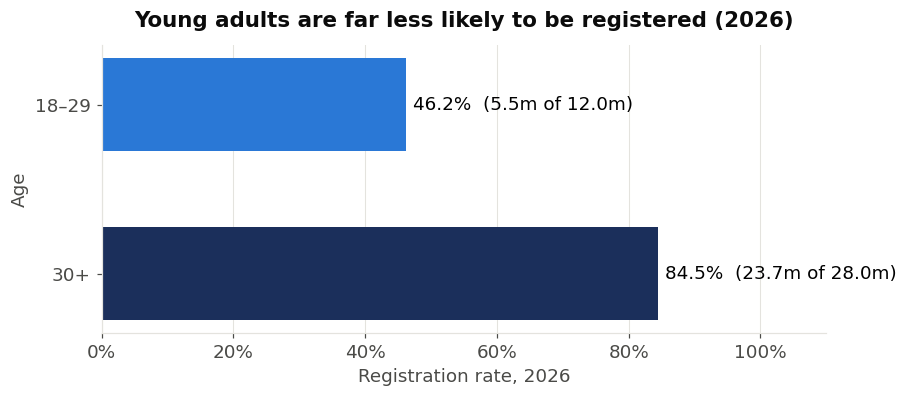

Youth rate below the 30+ rate in 212 of 213 municipalities


In [21]:
youth_reg, youth_elig = y26["registered_youth"].sum(), y26["eligible_youth"].sum()
ages = pd.DataFrame({"registered": [youth_reg, y26["registered"].sum() - youth_reg],
                     "eligible": [youth_elig, y26["eligible_adults"].sum() - youth_elig]},
                    index=["18–29", "30+"])
ages["rate"] = ages["registered"] / ages["eligible"]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
bars = ax.barh(ages.index, ages["rate"], height=0.55,
               color=[BLUE if a == "18–29" else NAVY for a in ages.index])
for rect, (a, row) in zip(bars, ages.iterrows()):
    ax.text(row["rate"] + 0.01, rect.get_y() + rect.get_height() / 2,
            f"{row['rate']:.1%}  ({row['registered'] / 1e6:.1f}m of {row['eligible'] / 1e6:.1f}m)", va="center")
ax.invert_yaxis(); ax.set_xlim(0, 1.1); pct(ax, "x"); tidy(ax, xgrid=True, ygrid=False)
ax.set(xlabel="Registration rate, 2026", ylabel=None, title="Young adults are far less likely to be registered (2026)")
ax.set(ylabel="Age")
save(fig, "q04_age_groups"); plt.show()

youth_rate = y26["registered_youth"] / y26["eligible_youth"]
older_rate = (y26["registered"] - y26["registered_youth"]) / (y26["eligible_adults"] - y26["eligible_youth"])
print(f"Youth rate below the 30+ rate in {(youth_rate < older_rate).sum()} of {len(y26)} municipalities")

What we found: young adults (18 to 29) register far less. 46% of them are registered (5.6 million of 12.0 million),
against 85% of adults aged 30 and older. Young adults register less than older adults in 212 of the 213
municipalities.

Keep in mind: this is registration only. We cannot tell whether young people who are registered vote less.

# C. What goes with low turnout

## Q5. Which things about a municipality go with low turnout?

A link is not proof of a cause. Patterns across municipalities cannot show why a person does or does not vote. So
we talk about what goes together with low turnout, not what causes it.

saved q05_correlations


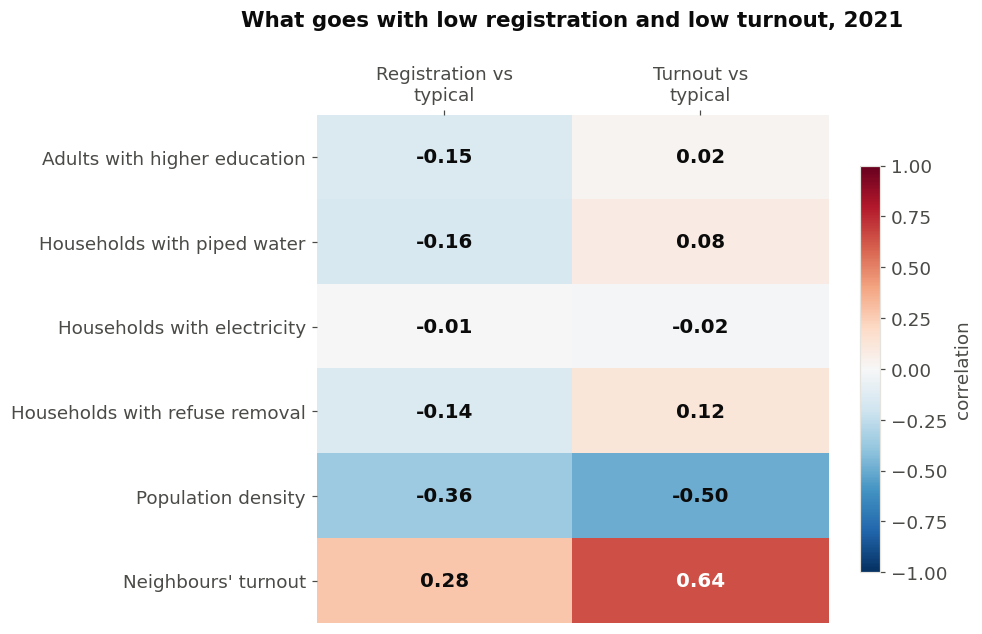

Registration gap vs turnout gap: 0.30
Water vs refuse removal: 0.78
                                Registration vs typical municipality  Turnout vs typical municipality
Adults with higher education                                   -0.15                             0.02
Households with piped water                                    -0.16                             0.08
Households with electricity                                    -0.01                            -0.02
Households with refuse removal                                 -0.14                             0.12
Population density                                             -0.36                            -0.50
Neighbours' turnout                                             0.28                             0.64


In [22]:
y21["log_density"] = np.log(y21["pop_density"])
chars = ["higher_ed_rate", "piped_water_rate", "electricity_rate", "refuse_removal_rate", "log_density",
         "spatial_lag_turnout"]
corr = y21[["leak_reg", "leak_turn"] + chars].corr().loc[chars, ["leak_reg", "leak_turn"]]

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks([0, 1], ["Registration vs\ntypical", "Turnout vs\ntypical"])
ax.set_yticks(range(len(chars)), [LABELS[c] for c in chars])
ax.xaxis.tick_top()
for i in range(len(chars)):
    for j in range(2):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=13, weight="bold",
                color="white" if abs(v) > .55 else INK)
ax.set_title("What goes with low registration and low turnout, 2021", pad=58)
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
save(fig, "q05_correlations"); plt.show()

print(f"Registration gap vs turnout gap: {y21['leak_reg'].corr(y21['leak_turn']):.2f}")
print(f"Water vs refuse removal: {y21['piped_water_rate'].corr(y21['refuse_removal_rate']):.2f}")
print(corr.rename(index=LABELS, columns=LABELS).round(2).to_string())

What we found:
- Registration and turnout are only loosely linked (correlation 0.30). They are mostly two different problems, so
  the turnout figure on its own is not enough to plan a response.
- Density matters most: denser municipalities had lower turnout in 2021 (-0.50), and the densest places also fell the
  most in 2021.
- Services and education have weak links with turnout in 2021 (0.02 to 0.12). Water and refuse removal move together
  (0.78), so we treat them as one "services" signal.
- Neighbours matter: a municipality's turnout is strongly linked to its neighbours' turnout (0.64, see Q6).

Keep in mind: these are simple correlations. In `08_model` (section 3b) we test each Census factor properly, with
density and province held constant. None of the services or education factors held up, so they are not in the
model. Better-serviced municipalities fell more in 2021 only, not before, which points to COVID hitting urban places
rather than services driving turnout.

## Q6. Does low turnout cluster in regions?

saved q06_clustering


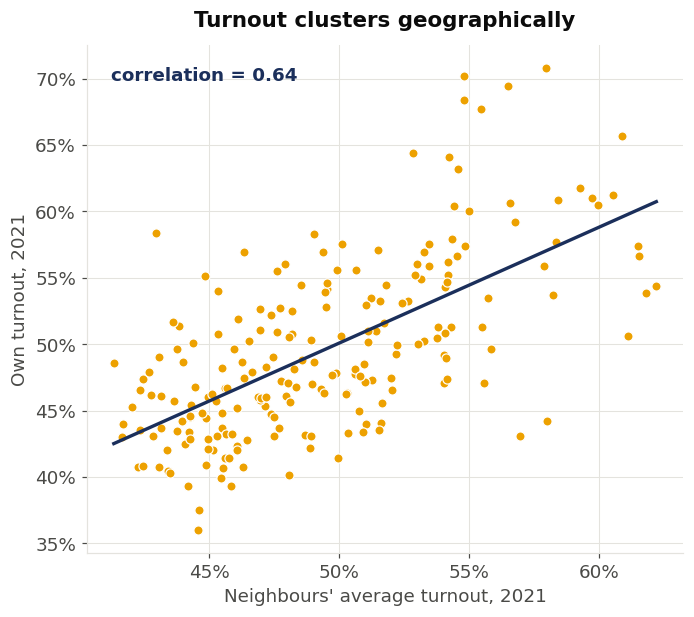

Same election: 0.64   |   neighbours' turnout at the previous election (2016): 0.54


In [23]:
sp = y21.dropna(subset=["spatial_lag_turnout", "t"])
rho = sp["t"].corr(sp["spatial_lag_turnout"])
lag_2016 = master[master["election"] == 2016].set_index("muni_code")["spatial_lag_turnout"]
rho_prev = sp["t"].corr(sp["muni_code"].map(lag_2016))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sp["spatial_lag_turnout"], sp["t"], s=36, color=AMBER, edgecolor=SURFACE, linewidth=0.8)
b, a = np.polyfit(sp["spatial_lag_turnout"], sp["t"], 1)
xs = np.linspace(sp["spatial_lag_turnout"].min(), sp["spatial_lag_turnout"].max(), 50)
ax.plot(xs, a + b * xs, color=NAVY, lw=2.2)
ax.annotate(f"correlation = {rho:.2f}", (0.04, 0.93), xycoords="axes fraction", fontsize=12, color=NAVY, weight="bold")
pct(ax); pct(ax, "x"); tidy(ax, xgrid=True)
ax.set(xlabel="Neighbours' average turnout, 2021", ylabel="Own turnout, 2021", title="Turnout clusters geographically")
save(fig, "q06_clustering"); plt.show()
print(f"Same election: {rho:.2f}   |   neighbours' turnout at the previous election (2016): {rho_prev:.2f}")

What we found: yes. A municipality's turnout is strongly linked to its neighbours' turnout in the same election
(correlation 0.64), and still clearly linked to their turnout at the previous election (0.54). Low turnout is
regional, for example across parts of Limpopo, North West and Mpumalanga.

Keep in mind: clustering suggests regional causes but does not tell us what they are. The model uses the neighbours'
turnout from the previous election, because nobody's 2026 turnout is known yet.

Was 2021 just COVID? `08_model` (section 8b) compares each municipality's 2024 national election turnout with its
2021 local turnout. In the cities the 2021 drop was COVID: by 2024 the densest municipalities were back to their
normal pattern. In rural municipalities turnout is really falling: the least dense are still about 10% below theirs.

## Q7. Does population density go with low turnout?

saved q07_density


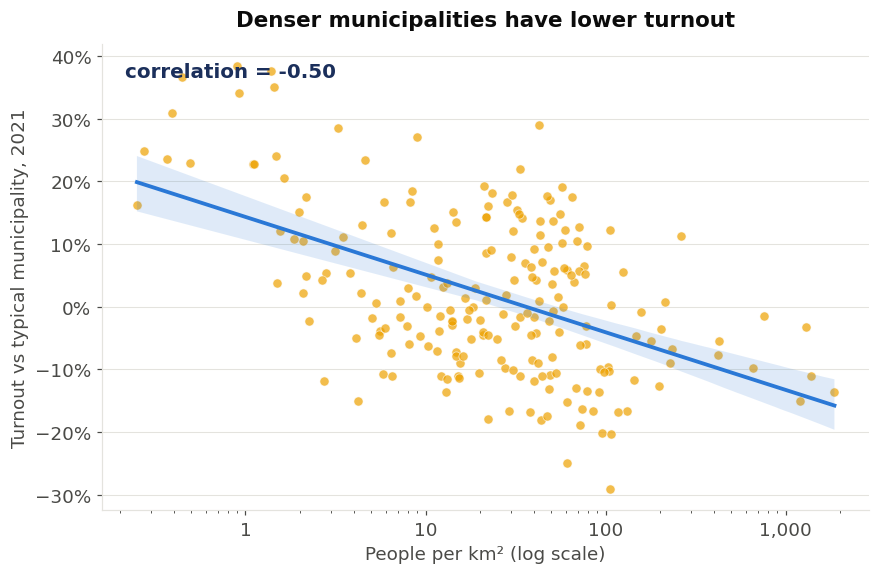

Correlation with log density: -0.497 (p-value 0.0000)


In [24]:
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mtick

d7 = y21.dropna(subset=["pop_density", "leak_turn"])
corr7, p7 = stats.pearsonr(np.log(d7["pop_density"]), d7["leak_turn"])

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.regplot(data=d7, x="pop_density", y="leak_turn", logx=True, ax=ax, ci=95,
            scatter_kws={"alpha": 0.7, "color": AMBER, "edgecolors": SURFACE, "linewidths": 0.5, "s": 36},
            line_kws={"color": BLUE, "linewidth": 2.5})           # the shaded band is the 95% range
ax.set_xscale("log")
ax.xaxis.set_major_locator(mtick.FixedLocator([1, 10, 100, 1000]))
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.text(0.03, 0.93, f"correlation = {corr7:.2f}", transform=ax.transAxes, fontsize=13, weight="bold", color=NAVY)
ax.set(title="Denser municipalities have lower turnout", xlabel="People per km² (log scale)",
       ylabel="Turnout vs typical municipality, 2021")
pct(ax); tidy(ax)
save(fig, "q07_density"); plt.show()
print(f"Correlation with log density: {corr7:.3f} (p-value {p7:.4f})")

What we found: denser municipalities had lower turnout than the typical municipality in 2021 (correlation -0.50).
Metros and big urban municipalities lost more voters between registering and voting than smaller ones.

Keep in mind: density stands for many things at once (city life, people moving, COVID rules in 2021), so this is a
link, not a cause. In 2024 the densest municipalities were back to their normal pattern, while rural ones are still
below theirs (`08_model`, section 8b).

# D. What to do

## Q8. Where should effort go before 4 November 2026?

There is no 2026 turnout yet, so we combine what we know now (the 2026 roll) with what happened last time (2021
turnout). Then we turn each gap into people: how many more registrations and how many more voters would bring the
municipality up to the typical level. (The dashboard uses the 2026 forecast instead of 2021 turnout.)

In [25]:
prio = y26[["muni_code", "muni_name", "province", "leak_reg", "r", "registered", "eligible_adults"]].merge(
    y21[["muni_code", "leak_turn", "t"]], on="muni_code")
prio["group"] = group_of(prio["leak_reg"], prio["leak_turn"])
prio["shortfall"] = -(prio["leak_reg"] + prio["leak_turn"])            # bigger = further below typical
r_typ, t_typ = prio["r"].median(), prio["t"].median()
prio["registrations_needed"] = (r_typ * prio["eligible_adults"] - prio["registered"]).clip(lower=0).round(-1)
prio["extra_voters_needed"] = ((t_typ - prio["t"]) * prio["registered"]).clip(lower=0).round(-1)
prio["what_to_send"] = prio["group"].map(WHAT_TO_SEND)

print(prio["group"].value_counts().reindex(GROUPS).to_string(), "\n")
top = prio.nlargest(15, "shortfall")
print(top[["muni_name", "province", "r", "t", "registrations_needed", "extra_voters_needed", "what_to_send"]]
      .assign(r=lambda d: (d["r"] * 100).round(1), t=lambda d: (d["t"] * 100).round(1))
      .rename(columns={"muni_name": "Municipality", "province": "Province", "r": "Registration 2026 %",
                       "t": "Turnout 2021 %", "registrations_needed": "Registrations needed",
                       "extra_voters_needed": "Extra voters needed", "what_to_send": "What to send"})
      .to_string(index=False))

group
Low registration    39
Low turnout         39
Both low            67
Healthy             68 

           Municipality      Province  Registration 2026 %  Turnout 2021 %  Registrations needed  Extra voters needed                            What to send
                Mkhondo    Mpumalanga                 48.8            43.1               49100.0               4060.0                   both - first priority
             Msukaligwa    Mpumalanga                 57.6            40.3               28300.0               6080.0                   both - first priority
        Thembisile Hani    Mpumalanga                 60.6            40.7               50610.0              12580.0                   both - first priority
               Emfuleni       Gauteng                 58.2            43.7              130790.0              16780.0                   both - first priority
               Mafikeng    North West                 67.8            37.6               24230.0              

What we found: the table shows the 15 municipalities furthest below the typical municipality on registration and
turnout together, with the registrations and extra voters each one needs, and what to send. 67 municipalities are
below typical on both, so they come first. Most of the top 15 are in Mpumalanga and Gauteng.

Keep in mind: "typical" means the middle (median) municipality, not a target set by the IEC. Registration rates
above 100% in a few small Northern Cape municipalities come from the Census sample, not from real over-registration.

Municipalities that are low on both registration and turnout come first, because they lose people at both steps:
fewer people get on the roll, and fewer of those vote.

What to do there: combine registration drives, help with IDs and proof of address, and voter education and
mobilisation.

In [26]:
print("Figures written to", FIGURES)
for f in sorted(FIGURES.glob("q0*.png")):
    print(" ", f.name)

Figures written to /content/drive/MyDrive/DIRISA_SDC/reports/figures
  q01_registration_turnout.png
  q02_provinces.png
  q03_lowest_turnout.png
  q04_age_groups.png
  q05_correlations.png
  q06_clustering.png
  q07_density.png
